In [1]:
#5.1 Myrmidon reef
#user inputs:Nikkis paper graphics keeping track.docx
#https://uq-my.sharepoint.com/:w:/r/personal/uqrbutto_uq_edu_au/Documents/PhD_proj_pollution_on_coral_reefs/Predicting%20changes%20in%20coral%20cover%20-%20Nikkis%20paper/Nikkis%20paper%20graphics%20keeping%20track.docx?d=wd96b4df36cde46dfb02dbc1aa1fa0583&csf=1&web=1&e=rgFboj

# Model name to be included in filenames
title = '5.1 Myrmidon'  # Update with each run

#issues in this script
##lack real data 2010 - temp fix add before and after values then divide by 2

#issues in user inputs 
##none

In [2]:
#loading reqs
from config import *
from utils import *

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Real data input from Overview of modelling data_2024 
#My real data
real_data = {
    'Year': range(MaxYear + 1),#start year + number of years model run for
    'RealBranching_Area (%)': [5.7,3.45,1.2,1.55,1.9,3,4.1,6.05,8,10.5,13,14.2,19.1,18.8,18.2,10],
    'RealFoliose_Area (%)': [2.6,2.4,2.2,2.2,2.2,2.45,2.7,2.7,2.7,2.55,2.4,2.7,2.2,2.8,3,3.3],
    'RealOther_Area (%)': [20.3,18.3,16.3,17.4,18.5,17.4,16.3,15.2,14.1,13.5,12.9,17.2,13.9,15.4,17.9,21.6] 
}
real_df = pd.DataFrame(real_data)

In [5]:
# Define the output directory
output_dir = r"C:\Users\uqrbutto\OneDrive - The University of Queensland\PhD_proj_pollution_on_coral_reefs\Coral_model_Rios_branch_1\Brown_etal_2025_outputs"

# Ensure the directory exists
os.makedirs(output_dir, exist_ok=True)

In [6]:
#create all df's from the same 100 model runs


# Function to run the model 100 times and collect the results
def run_model_100_times():
    population_results = []
    percentage_population_results = []
    area_results = []
    final_results = []
    
    for _ in range(100):
        coral_model_results = run_coral_model(PSD_T0, MaxYear)
        benthic_cover_results = opts.yearly_benthic_cover_df
        rugosity_results = get_rugosity_list()
        
        # Merge the results into a single DataFrame
        merged_results = pd.merge(coral_model_results, benthic_cover_results, on='Year')
        merged_results['Rugosity'] = rugosity_results
        
        final_results.append(merged_results)
        
        # Collect population, percentage population, and area results
        for year in range(MaxYear + 1):
            population_df = opts.yearly_population_df_list[year]
            surface_area_df = opts.yearly_surface_area_df_list[year]
            
            for mg in ['Branching', 'Foliose', 'Other']:
                # Population Size DataFrame
                pop_size_row = [mg, year] + population_df[mg].tolist()
                population_results.append(pop_size_row)
                
                # Percentage Population Size DataFrame
                total_pop = population_df[mg].sum()
                perc_pop_size_row = [mg, year] + (100 * population_df[mg] / total_pop).tolist()
                percentage_population_results.append(perc_pop_size_row)
                
                # Area DataFrame
                area_row = [mg, year] + surface_area_df[mg].tolist()
                area_results.append(area_row)
    
    # Concatenate all the results into a single DataFrame
    final_df = pd.concat(final_results)
    
    return final_df, population_results, percentage_population_results, area_results

# Run the model 100 times and get the results
final_df, population_results, percentage_population_results, area_results = run_model_100_times()

# Create dataframes for population size, percentage population size, and area
bin_diameters = [i * binSize for i in range(MaxBinId)]
columns = ['MG', 'Year'] + [f'Bin Diameter {d} (cm)' for d in bin_diameters]

population_size_df = pd.DataFrame(population_results, columns=columns)
percentage_population_size_df = pd.DataFrame(percentage_population_results, columns=columns)
area_df = pd.DataFrame(area_results, columns=columns)

# Print the dataframes
print("Final DataFrame")
print(final_df)

print("\nPopulation Size DataFrame")
print(population_size_df)

print("\nPercentage Population Size DataFrame")
print(percentage_population_size_df)

print("\nArea DataFrame")
print(area_df)


Final DataFrame
    Year  Branching_Area (%)  Foliose_Area (%)  Other_Area (%)  \
0      0            5.700000          2.600000       20.300000   
1      1            0.963855          2.093817       17.178818   
2      2            1.149450          2.038285       16.865817   
3      3            1.404812          2.033239       17.081085   
4      4            1.671641          2.053571       16.848293   
..   ...                 ...               ...             ...   
11    11            4.861242          2.309787       17.557723   
12    12            5.805221          2.407815       17.582002   
13    13            6.929283          2.518497       17.583033   
14    14            8.243431          2.628904       17.760444   
15    15            4.300507          2.319448       15.127701   

    total_coral_cover (%)  total_benthic_cover (%)  available_substrate (%)  \
0               28.600000                71.400000                54.600000   
1               20.236490        

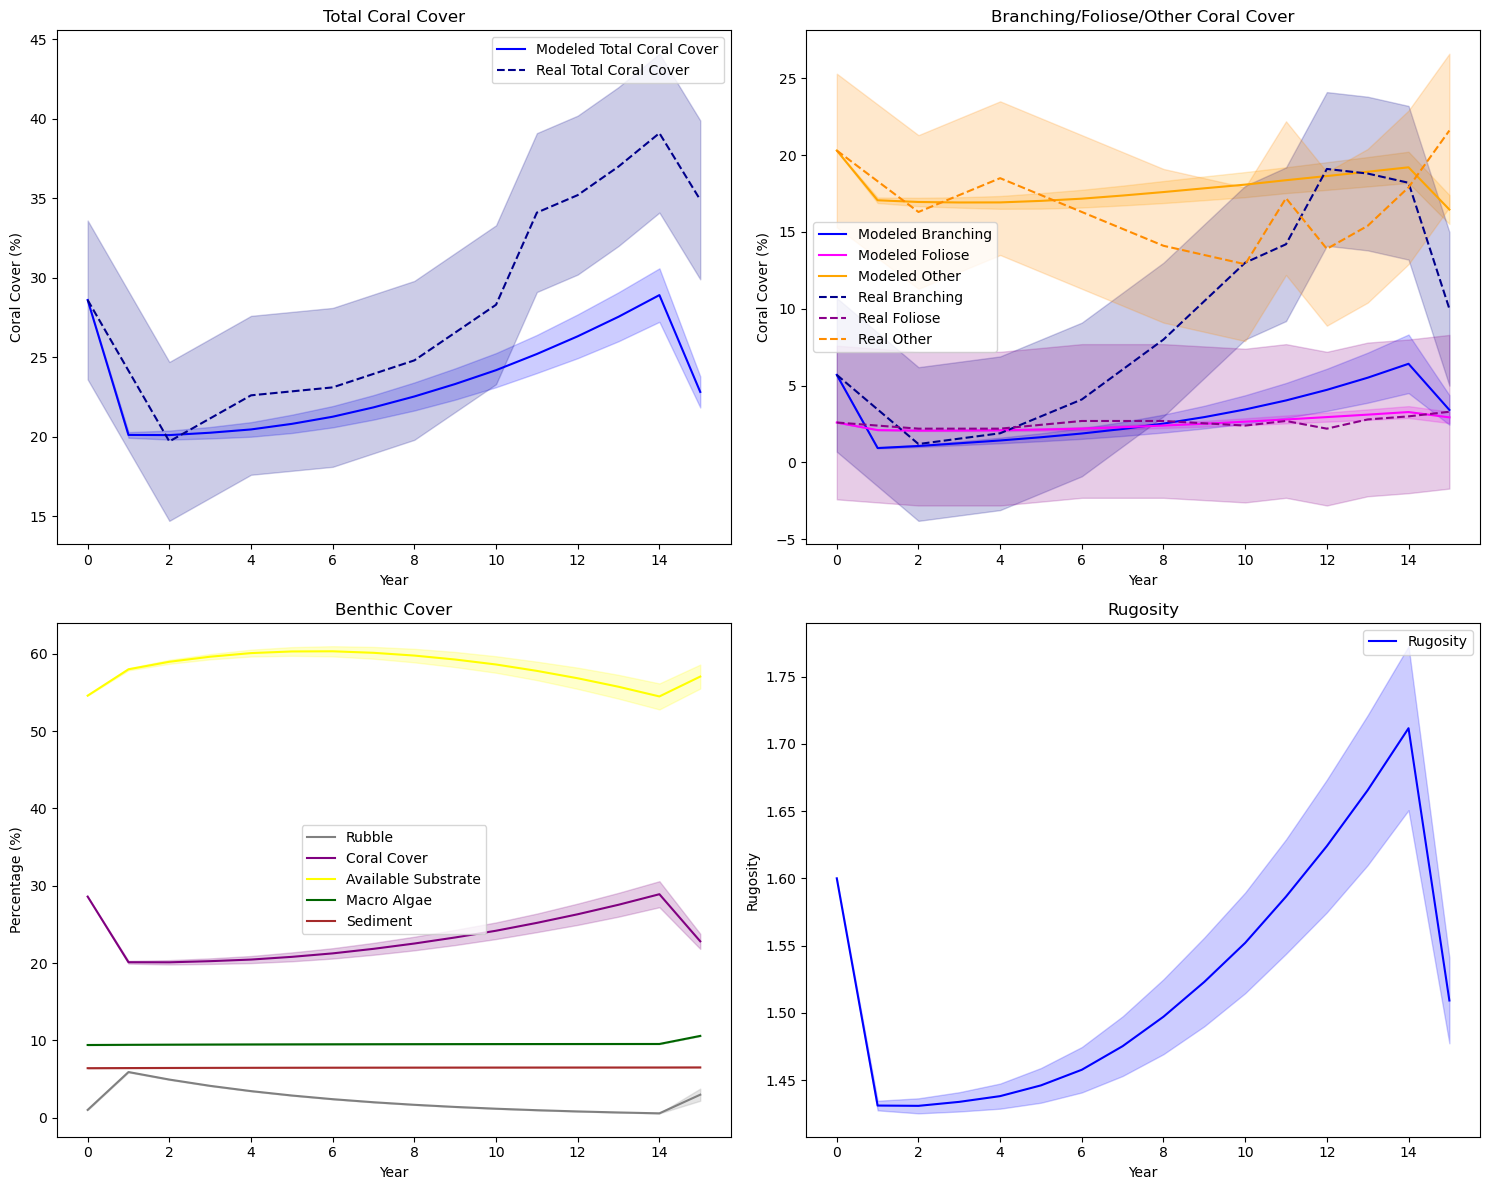

In [7]:
#plating 2x2 cc, mg, rug, benthic



# Assuming final_df and real_df are already defined DataFrames
# Calculate the total coral cover for modeled data
final_df['Total_Coral_Cover (%)'] = final_df['Branching_Area (%)'] + final_df['Foliose_Area (%)'] + final_df['Other_Area (%)']

# Calculate the total coral cover for real data
real_df['Total_Coral_Cover (%)'] = real_df['RealBranching_Area (%)'] + real_df['RealFoliose_Area (%)'] + real_df['RealOther_Area (%)']

# Calculate the average and standard deviation for each morphology
average_branching = final_df.groupby('Year')['Branching_Area (%)'].mean()
std_dev_branching = final_df.groupby('Year')['Branching_Area (%)'].std()

average_foliose = final_df.groupby('Year')['Foliose_Area (%)'].mean()
std_dev_foliose = final_df.groupby('Year')['Foliose_Area (%)'].std()

average_other = final_df.groupby('Year')['Other_Area (%)'].mean()
std_dev_other = final_df.groupby('Year')['Other_Area (%)'].std()

average_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].mean()
std_dev_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].std()

# Calculate the margins for real data (5% absolute above and below)
absolute_margin = 5

real_branching_margin = absolute_margin
real_foliose_margin = absolute_margin
real_other_margin = absolute_margin
real_total_margin = absolute_margin

# Create a figure with 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

years = average_branching.index

# Plot Total Coral Cover
axs[0, 0].plot(years, average_total, label='Modeled Total Coral Cover', color='blue')
axs[0, 0].fill_between(years, average_total - std_dev_total, average_total + std_dev_total, color='blue', alpha=0.2)
axs[0, 0].plot(real_df['Year'], real_df['Total_Coral_Cover (%)'], label='Real Total Coral Cover', color='darkblue', linestyle='--')
axs[0, 0].fill_between(real_df['Year'], real_df['Total_Coral_Cover (%)'] - real_total_margin, real_df['Total_Coral_Cover (%)'] + real_total_margin, color='darkblue', alpha=0.2)
axs[0, 0].set_title('Total Coral Cover')
axs[0, 0].set_xlabel('Year')
axs[0, 0].set_ylabel('Coral Cover (%)')
axs[0, 0].legend()

# Plot Branching, Foliose, and Other Coral Cover
axs[0, 1].plot(years, average_branching, label='Modeled Branching', color='blue')
axs[0, 1].fill_between(years, average_branching - std_dev_branching, average_branching + std_dev_branching, color='blue', alpha=0.2)
axs[0, 1].plot(years, average_foliose, label='Modeled Foliose', color='fuchsia')
axs[0, 1].fill_between(years, average_foliose - std_dev_foliose, average_foliose + std_dev_foliose, color='fuchsia', alpha=0.2)
axs[0, 1].plot(years, average_other, label='Modeled Other', color='orange')
axs[0, 1].fill_between(years, average_other - std_dev_other, average_other + std_dev_other, color='orange', alpha=0.2)
axs[0, 1].plot(real_df['Year'], real_df['RealBranching_Area (%)'], label='Real Branching', color='darkblue', linestyle='--')
axs[0, 1].fill_between(real_df['Year'], real_df['RealBranching_Area (%)'] - real_branching_margin, real_df['RealBranching_Area (%)'] + real_branching_margin, color='darkblue', alpha=0.2)
axs[0, 1].plot(real_df['Year'], real_df['RealFoliose_Area (%)'], label='Real Foliose', color='darkmagenta', linestyle='--')
axs[0, 1].fill_between(real_df['Year'], real_df['RealFoliose_Area (%)'] - real_foliose_margin, real_df['RealFoliose_Area (%)'] + real_foliose_margin, color='darkmagenta', alpha=0.2)
axs[0, 1].plot(real_df['Year'], real_df['RealOther_Area (%)'], label='Real Other', color='darkorange', linestyle='--')
axs[0, 1].fill_between(real_df['Year'], real_df['RealOther_Area (%)'] - real_other_margin, real_df['RealOther_Area (%)'] + real_other_margin, color='darkorange', alpha=0.2)
axs[0, 1].set_title('Branching/Foliose/Other Coral Cover')
axs[0, 1].set_xlabel('Year')
axs[0, 1].set_ylabel('Coral Cover (%)')
axs[0, 1].legend()

# Plot Benthic Cover
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()
average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()
average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()
average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()
average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()

years_benthic = average_rubble.index

axs[1, 0].plot(years_benthic, average_rubble, label='Rubble', color='grey')
axs[1, 0].fill_between(years_benthic, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)
axs[1, 0].plot(years_benthic, average_coral_cover, label='Coral Cover', color='purple')
axs[1, 0].fill_between(years_benthic, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)
axs[1, 0].plot(years_benthic, average_as, label='Available Substrate', color='yellow')
axs[1, 0].fill_between(years_benthic, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)
axs[1, 0].plot(years_benthic, average_ma, label='Macro Algae', color='darkgreen')
axs[1, 0].fill_between(years_benthic, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)
axs[1, 0].plot(years_benthic, average_sediment, label='Sediment', color='brown')
axs[1, 0].fill_between(years_benthic, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)
axs[1, 0].set_title('Benthic Cover')
axs[1, 0].set_xlabel('Year')
axs[1, 0].set_ylabel('Percentage (%)')
axs[1, 0].legend()

# Plot Rugosity
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

axs[1, 1].plot(years, average_rugosity, label='Rugosity', color='blue')
axs[1, 1].fill_between(years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)
axs[1, 1].set_title('Rugosity')
axs[1, 1].set_xlabel('Year')
axs[1, 1].set_ylabel('Rugosity')
axs[1, 1].legend()

# Adjust layout
plt.tight_layout()

# Define the graph directory path
graph_dir = r'C:\\Users\\uqrbutto\\OneDrive - The University of Queensland\\PhD_proj_pollution_on_coral_reefs\\Coral_model_Rios_branch_1\\happyreef_testing\\plots'

# Create the directory if it doesn't exist
os.makedirs(graph_dir, exist_ok=True)

# Save the combined plot to the specified folder
graph_path = os.path.join(output_dir, f'{title}-cover_rugosity.png')
plt.savefig(graph_path)
plt.show()



In [10]:
def plot_graphs_with_std_shades(df, y_label, y_unit, filename_suffix):
    bin_diameters = [i * binSize for i in range(MaxBinId)]
    
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    
    for idx, mg in enumerate(['Branching', 'Foliose', 'Other']):
        for year in [0,1, 8, 13,14]:
            year_df = df[(df['MG'] == mg) & (df['Year'] == year)]
            mean_values = year_df.iloc[:, 2:].mean()
            std_values = year_df.iloc[:, 2:].std()
            
            axs[idx].plot(bin_diameters, mean_values, label=f'Year {year}')
            axs[idx].fill_between(bin_diameters, mean_values - std_values, mean_values + std_values, alpha=0.2)
        
        axs[idx].set_title(f'{mg} {y_label} Over Time')
        axs[idx].set_xlabel('Bin Diameter (cm)')
        axs[idx].set_ylabel(f'{y_label} {y_unit}')
        axs[idx].legend()
    
    plt.tight_layout()
    
    # Save the figure with the full path
    graph_path = os.path.join(output_dir, f'{title}-{filename_suffix}.png')
    plt.savefig(graph_path)
    plt.show()


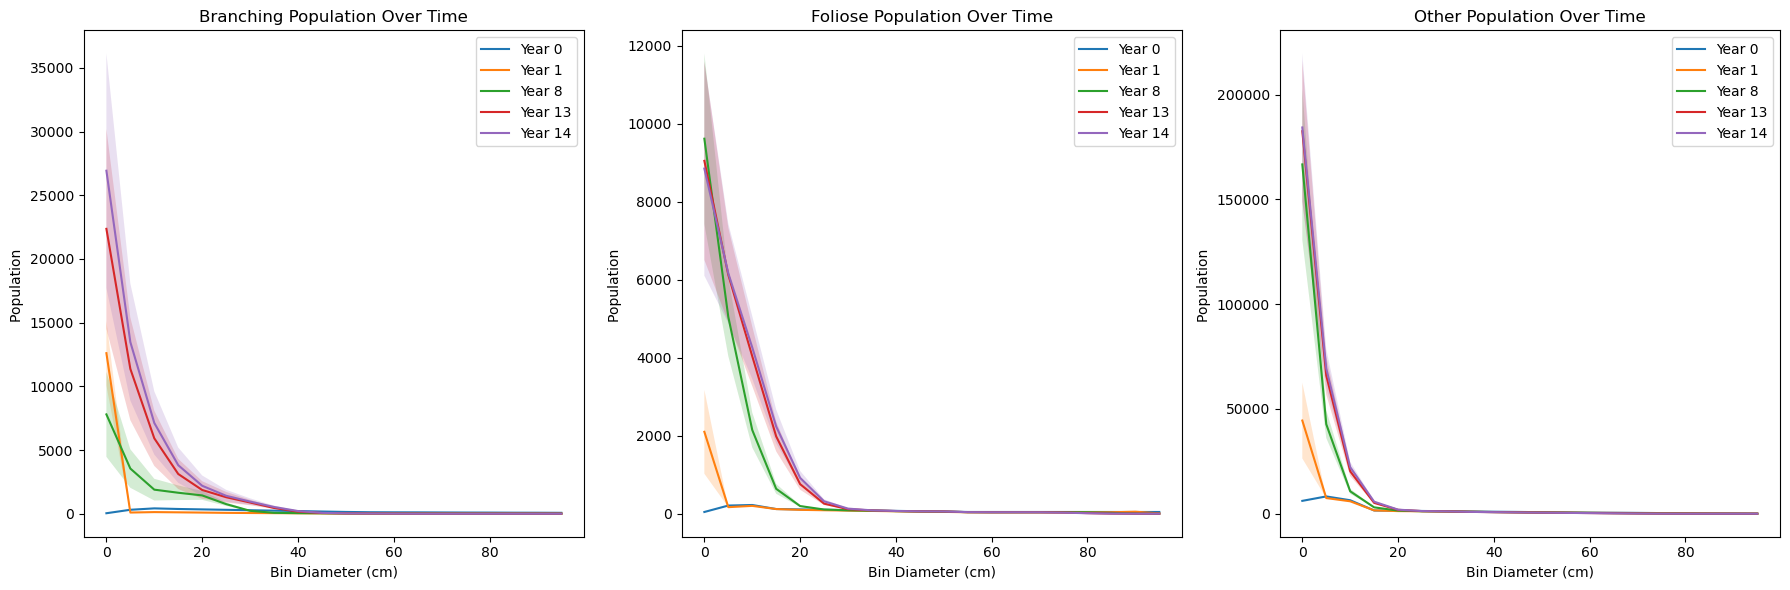

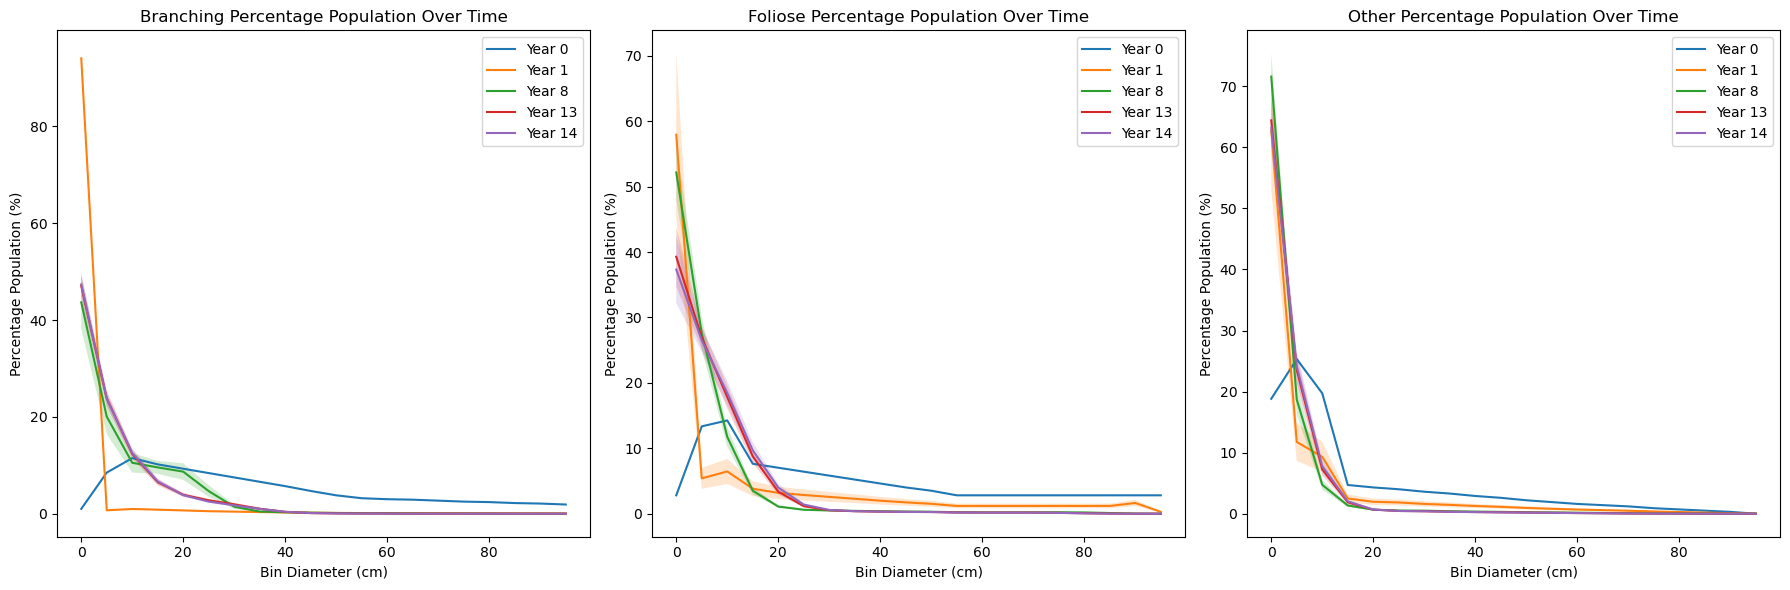

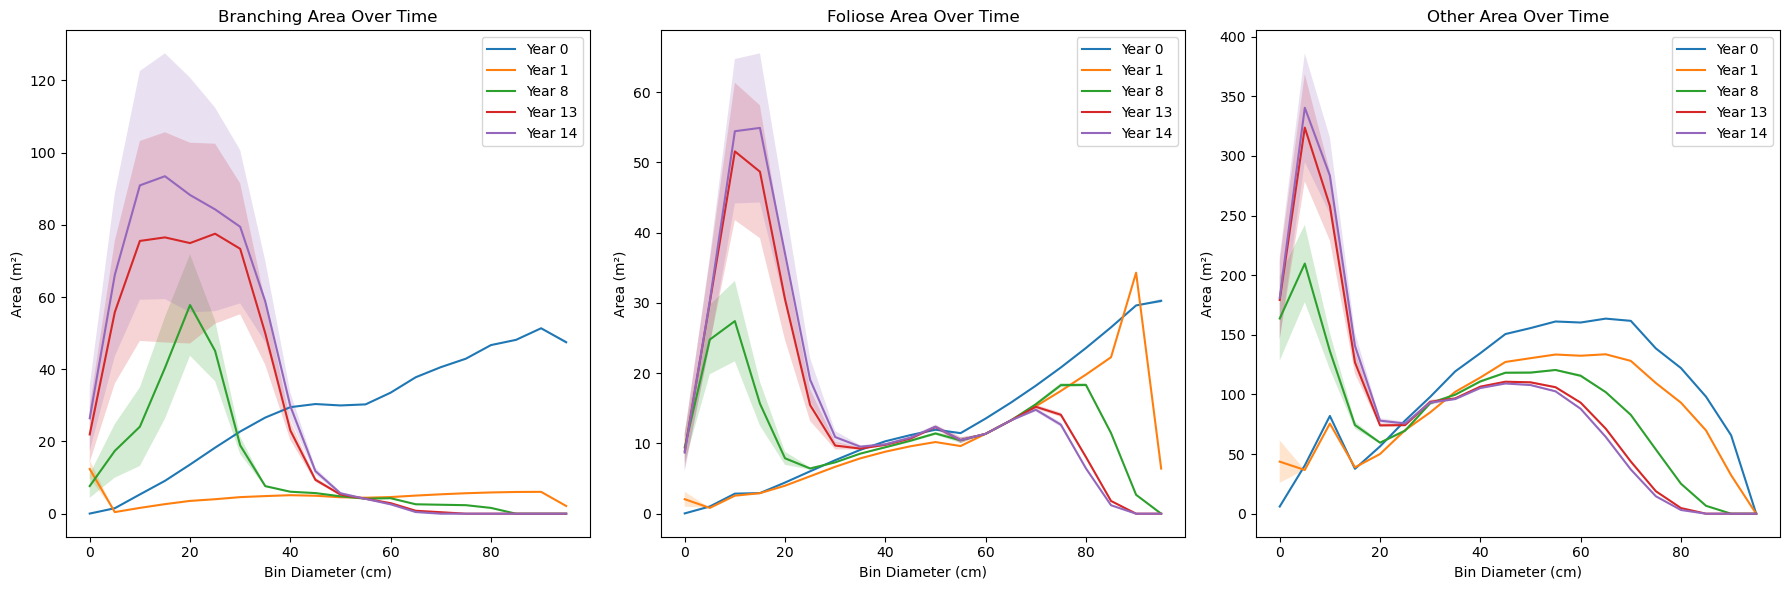

In [11]:
plot_graphs_with_std_shades(population_size_df, 'Population', '', 'population')
plot_graphs_with_std_shades(percentage_population_size_df, 'Percentage Population', '(%)', 'percentage_population')
plot_graphs_with_std_shades(area_df, 'Area', '(m²)', 'area')